In [ ]:
!pip install qiskit qiskit-ibm-runtime qiskit-algorithms pylatexenc qiskit-aer
!pip install pandas scikit-learn matplotlib seaborn rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ece419c317e18c31d9a896c5c413f88534c641790c964d8374b238eb1e92b272
  Stored in 

Target Backend: ibm_kingston
Generating and transpiling circuits...
Submitting batch job (40 PUBs) to ibm_kingston...
Job ID: d6uhfraf84ks73de99kg (Waiting for execution...)
Processing hardware results...

--- SHOT BUDGET CONVERGENCE: P_peak = max_k P(k) ---
Shots          1024    2048    4096    8192
Molecule                                   
Aspirin      0.0215  0.0347  0.0259  0.0258
Benzene      0.3408  0.3257  0.3313  0.3296
Caffeine     0.0098  0.0112  0.0071  0.0066
Dopamine     0.0488  0.0581  0.0474  0.0468
Glucose      0.0166  0.0264  0.0242  0.0245
Glycerol     0.1104  0.1201  0.1101  0.1185
Ibuprofen    0.0498  0.0625  0.0547  0.0587
Nicotine     0.0391  0.0327  0.0415  0.0398
Paracetamol  0.0303  0.0264  0.0251  0.0217
Urea         0.2002  0.1919  0.1882  0.1958


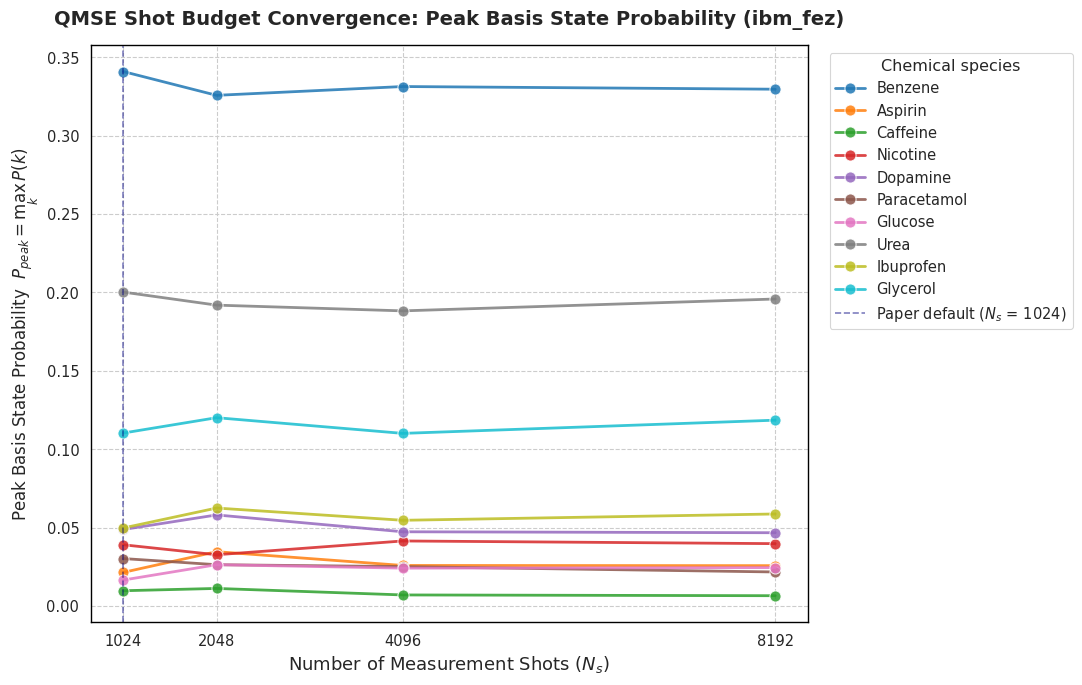

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# --- CONFIGURATION ---
EN_MAP = {'H': 2.20, 'Li': 0.98, 'Be': 1.57, 'B': 2.04, 'C': 2.55,
          'N': 3.04, 'O': 3.44, 'F': 3.98, 'S': 2.58, 'Cl': 3.16}


ALPHA = 0.1

N_QUBITS = 12
SHOT_BUDGETS = [1024, 2048, 4096, 8192]
molecules = {
    "Benzene":     "C1=CC=C1",
    "Aspirin":     "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Caffeine":    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
    "Nicotine":    "CN1CCCC1C2=CN=CC=C2",
    "Dopamine":    "C1=CC(=C(C=C1CCN)O)O",
    "Paracetamol": "CC(=O)NC1=CC=C(O)C=C1",
    "Glucose":     "C(C1C(C(C(C(O1)O)O)O)O)O",
    "Urea":        "C(=O)(N)N",
    "Ibuprofen":   "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Glycerol":    "C(C(CO)O)O"
}


def qmse_10_plus_2(smiles):

    mol = Chem.MolFromSmiles(smiles)
    qc = QuantumCircuit(N_QUBITS)
    if not mol:
        return qc

    atoms = list(mol.GetAtoms())
    n_exact = 10
    backbone = atoms[:n_exact]
    tail = atoms[n_exact:]
    mol_to_qubit = {atom.GetIdx(): i for i, atom in enumerate(backbone)}

    # Stage 1: Backbone encoding — θᵢ = α · χᵢ² for i ∈ {0,…,9}
    for atom in backbone:
        en = EN_MAP.get(atom.GetSymbol(), 1.0)
        qc.ry(ALPHA * (en ** 2), mol_to_qubit[atom.GetIdx()])

    # Stage 2: Tail summary encoding — θ = (α/2) · Σχ, alternating split
    if tail:
        tail_A, tail_B = tail[0::2], tail[1::2]
        if tail_A:
            qc.ry((ALPHA / 2) * sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in tail_A), 10)
        if tail_B:
            qc.ry((ALPHA / 2) * sum(EN_MAP.get(a.GetSymbol(), 1.0) for a in tail_B), 11)

    # Stage 3: Topological entanglement — ϕᵢⱼ = wᵢⱼ/2 for ALL bonds

    for bond in mol.GetBonds():
        idx1, idx2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        q1, q2 = mol_to_qubit.get(idx1), mol_to_qubit.get(idx2)
        phi_ij = bond.GetBondTypeAsDouble() / 2

        if q1 is not None and q2 is not None:
            qc.rxx(phi_ij, q1, q2)
        elif q1 is not None:
            qc.rxx(phi_ij, q1, 10)
            qc.rxx(phi_ij, q1, 11)
        elif q2 is not None:
            qc.rxx(phi_ij, q2, 10)
            qc.rxx(phi_ij, q2, 11)

    qc.measure_all()
    return qc


# --- HARDWARE PREPARATION ---
token    = "API"
instance = "CRN"
try:
    QiskitRuntimeService.save_account(
        token=token, channel="ibm_cloud",
        instance=instance, name="open-instance", overwrite=True
    )
except:
    pass

service    = QiskitRuntimeService(name="open-instance")
hw_backend = service.backend("ibm_kingston")
print(f"Target Backend: {hw_backend.name}")

pm = generate_preset_pass_manager(
    backend=hw_backend,
    optimization_level=1,
    seed_transpiler=42
)

print("Generating and transpiling circuits...")
isa_circuits_dict = {}
for name, smiles in molecules.items():
    qc = qmse_10_plus_2(smiles)
    isa_circuits_dict[name] = pm.run(qc)

# --- BATCH JOB CREATION ---
# All molecules × all shot budgets packed into ONE job
# This ensures all measurements share the same hardware calibration snapshot
pubs     = []
metadata = []

for shots in SHOT_BUDGETS:
    for name, isa_qc in isa_circuits_dict.items():
        # SamplerV2 PUB format: (circuit, parameter_values, shots)
        pubs.append((isa_qc, None, shots))
        metadata.append({"Molecule": name, "Shots": shots})

print(f"Submitting batch job ({len(pubs)} PUBs) to {hw_backend.name}...")
sampler_hw = RuntimeSampler(mode=hw_backend)
job = sampler_hw.run(pubs)
print(f"Job ID: {job.job_id()} (Waiting for execution...)")
result_hw = job.result()

# --- EXTRACT AND PROCESS RESULTS ---
print("Processing hardware results...")
results_data = []

for i, pub_result in enumerate(result_hw):
    shots_used = metadata[i]["Shots"]
    counts     = pub_result.data.meas.get_counts()

    # P_peak = max_k P(k) where P(k) = counts(k) / N_shots
    # Serves as a proxy for quantum signal coherence under finite sampling
    p_peak = max(counts.values()) / shots_used

    row = metadata[i].copy()
    row["P_peak"] = p_peak
    results_data.append(row)

df_plot = pd.DataFrame(results_data)

# Pivot table for quick inspection
pivot_df = df_plot.pivot(index="Molecule", columns="Shots", values="P_peak")
print("\n--- SHOT BUDGET CONVERGENCE: P_peak = max_k P(k) ---")
print(pivot_df.round(4))
pivot_df.to_csv("shot_convergence_data.csv")

# --- VISUALIZATION ---
plt.figure(figsize=(11, 7))
sns.set_context("paper", font_scale=1.2)
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--', 'axes.edgecolor': 'black'})

sns.lineplot(
    data=df_plot, x="Shots", y="P_peak", hue="Molecule",
    marker="o", markersize=8, linewidth=2,
    palette="tab10", alpha=0.85
)

plt.title(
    "QMSE Shot Budget Convergence: Peak Basis State Probability (ibm_fez)",
    fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Number of Measurement Shots ($N_s$)", fontsize=13)
plt.ylabel(r"Peak Basis State Probability  $P_{peak} = \max_k\, P(k)$", fontsize=12)
plt.xticks(SHOT_BUDGETS, [str(s) for s in SHOT_BUDGETS])


plt.axvline(
    x=1024, color="navy", linestyle="--", alpha=0.5,
    label="Paper default ($N_s$ = 1024)"
)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True, title="Chemical species")
plt.tight_layout()
plt.savefig("shot_convergence_ibm_fez.png", dpi=300, bbox_inches="tight")
plt.show()

Saved: convergence_matrix_ieee.png


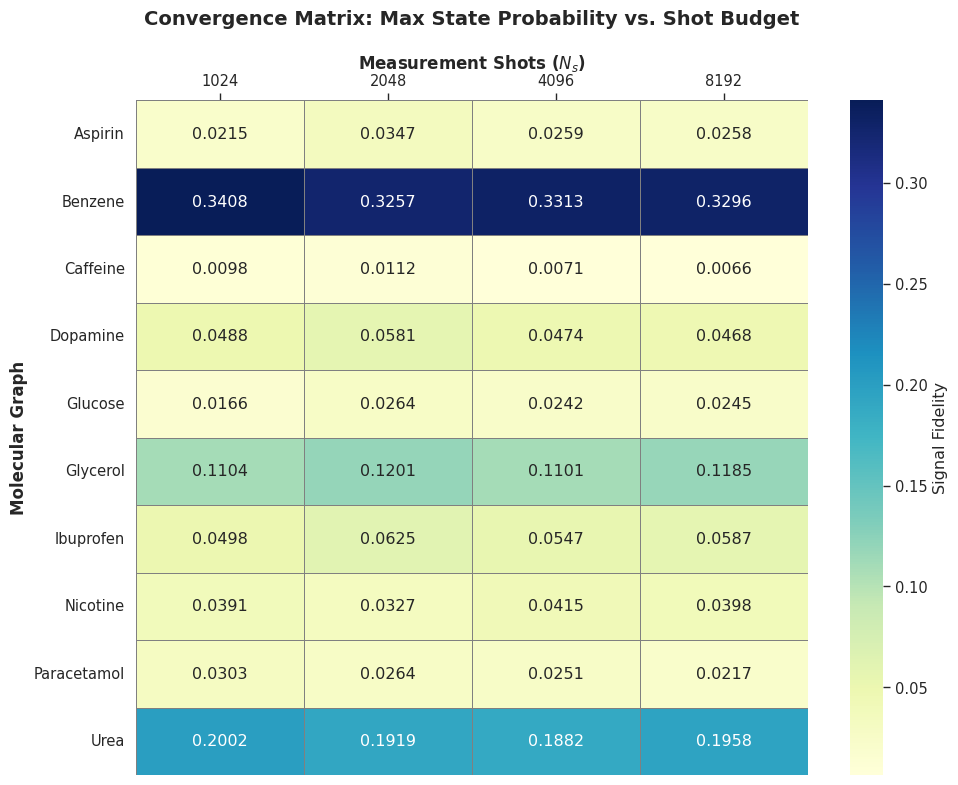

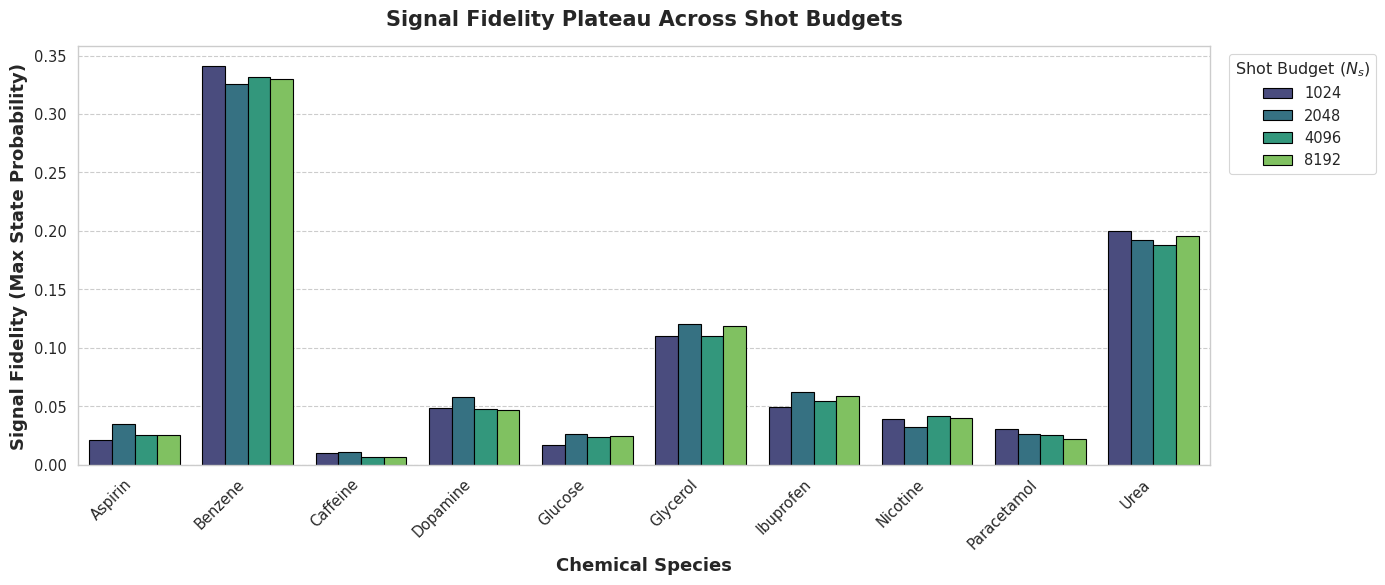

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. LOAD THE DATA ---

try:
    df_matrix = pd.read_csv('shot_convergence_data.csv', index_col='Molecule')
except FileNotFoundError:
    print("Error: 'shot_convergence_data.csv' not found. Ensure it is in the same folder.")
    exit()

# Ensure columns are strings for plotting categorical data
df_matrix.columns = [str(col) for col in df_matrix.columns]

# --- 2. FIGURE 1: THE CONVERGENCE MATRIX (HEATMAP) ---
plt.figure(figsize=(10, 8))
sns.set_context("paper", font_scale=1.2)


ax = sns.heatmap(df_matrix, annot=True, fmt=".4f", cmap="YlGnBu",
                 linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Signal Fidelity'})


ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.title('Convergence Matrix: Max State Probability vs. Shot Budget', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Measurement Shots ($N_s$)', fontsize=12, fontweight='bold')
plt.ylabel('Molecular Graph', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('convergence_matrix.png', dpi=300, bbox_inches='tight')
print("Saved: convergence_matrix.png")
plt.show()


# --- 3. FIGURE 2: GROUPED BAR CHART ---

df_long = df_matrix.reset_index().melt(id_vars='Molecule', var_name='Shots', value_name='Fidelity')

plt.figure(figsize=(14, 6))
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})

# Create the grouped bar chart
sns.barplot(data=df_long, x='Molecule', y='Fidelity', hue='Shots',
            palette='viridis', edgecolor='black', linewidth=0.8)

plt.title('Signal Fidelity Plateau Across Shot Budgets', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Chemical Species', fontsize=13, fontweight='bold')
plt.ylabel('Signal Fidelity (Max State Probability)', fontsize=13, fontweight='bold')


plt.legend(title='Shot Budget ($N_s$)', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
plt.xticks(rotation=45, ha='right') # Angle the molecule names

plt.tight_layout()

plt.show()
